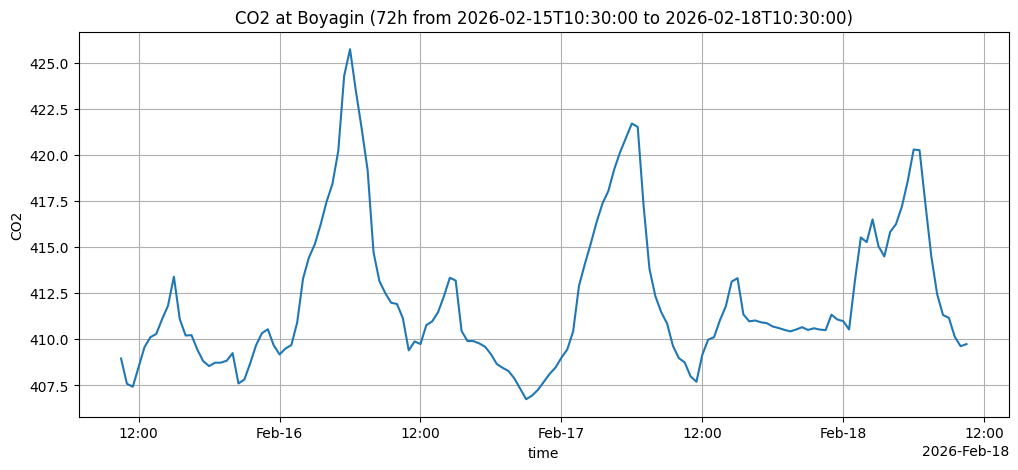

In [1]:
from terndata import flux
import matplotlib.pyplot as plt
import numpy as np

subset_CO2 = flux.get_subset("Boyagin",  "2026_v2", "L6", ["CO2"], start="2026-02-15T10:30:00", end="2026-02-18T10:30:00", keep_qcflags=False)
subset_CO2

subset_CO2["CO2"].squeeze(["latitude", "longitude"], drop=True).plot.line(
    figsize=(12, 5)
)
plt.title("CO2 at Boyagin (72h from 2026-02-15T10:30:00 to 2026-02-18T10:30:00)")
plt.ylabel("CO2")
plt.grid()
plt.show()

In [ ]:
# Gross Primary Production (GPP): The total carbon uptake by plants through photosynthesis 
flux.get_attributes("Boyagin", "2026_v2", "L6", ["GPP_LL", "GPP_LT", "GPP_SOLO"])

{'GPP_LL': {'_CoordinateAxes': 'time latitude longitude ',
  'description_L6': 'Calculated as -1*NEE_LL + ER_LL',
  'long_name': 'Gross Primary Productivity',
  'statistic_type': 'average',
  'coverage_L6': '100%',
  'units': 'umol/m^2/s'},
 'GPP_LT': {'_CoordinateAxes': 'time latitude longitude ',
  'units': 'umol/m^2/s',
  'coverage_L6': '100%',
  'description_L6': 'Calculated as -1*NEE_LT + ER_LT',
  'long_name': 'Gross Primary Productivity',
  'statistic_type': 'average'},
 'GPP_SOLO': {'_CoordinateAxes': 'time latitude longitude ',
  'coverage_L6': '100%',
  'description_L6': 'Calculated as -1*NEE_SOLO + ER_SOLO',
  'long_name': 'Gross Primary Productivity',
  'statistic_type': 'average',
  'units': 'umol/m^2/s'}}

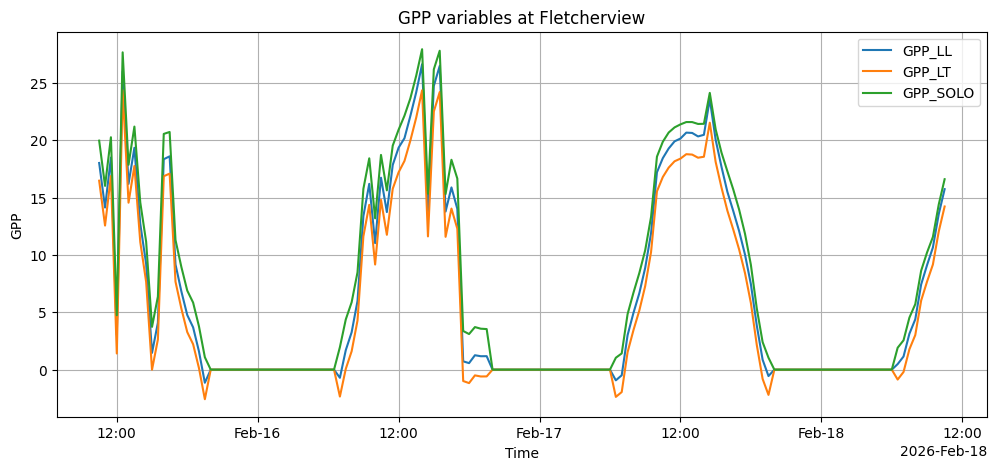

In [26]:
subset_CO2 = flux.get_subset("Fletcherview",  "2026_v2", "L6", ["GPP_LL", "GPP_LT", "GPP_SOLO"], start="2026-02-15T10:30:00", end="2026-02-18T10:30:00")
subset_CO2
gpp_vars = ["GPP_LL", "GPP_LT", "GPP_SOLO"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(12, 5))

for variable, color in zip(gpp_vars, colors):
    if variable in subset_CO2:
        subset_CO2[variable].squeeze(
            ["latitude", "longitude"], drop=True
        ).plot.line(ax=ax, color=color, label=variable)

ax.set_title("GPP variables at Fletcherview")
ax.set_xlabel("Time")
ax.set_ylabel("GPP")
ax.grid()
ax.legend()
plt.show()

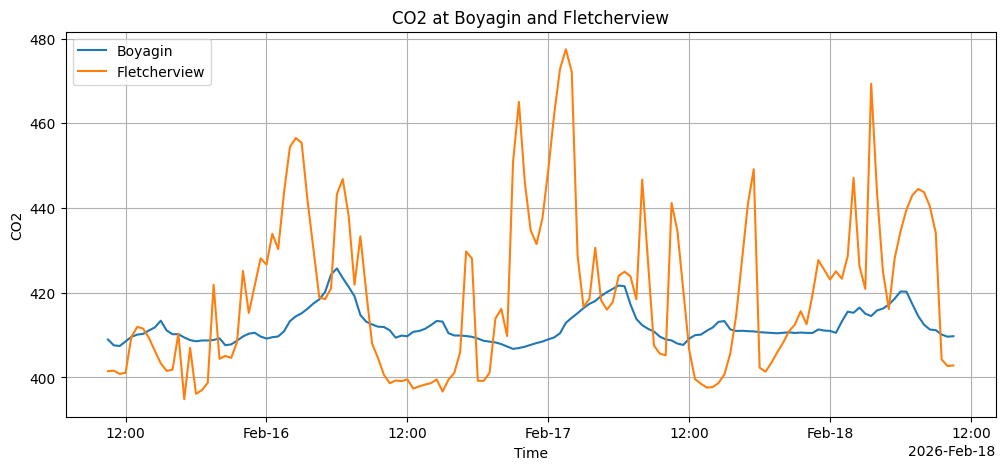

In [ ]:
# Fletcherview and Boyagin CO2 flux comparison
# Fletcherview: open savanna woodland, Boyagin: Wandoo Woodland

subset_CO2 = flux.get_subsets(["Boyagin", "Fletcherview"],  "2026_v2", "L6", ["CO2"], start="2026-02-15T10:30:00", end="2026-02-18T10:30:00")
subset_CO2

for site, site_ds in subset_CO2.items():
    if site == next(iter(subset_CO2)):
        fig, ax = plt.subplots(figsize=(12, 5))

    site_ds["CO2"].squeeze(["latitude", "longitude"], drop=True).plot.line(
        ax=ax,
        color=plt.cm.tab10(list(subset_CO2).index(site)),
        label=site,
    )

    ax.set_title("CO2 at Boyagin and Fletcherview")
    ax.set_xlabel("Time")
    ax.set_ylabel("CO2")
    ax.legend()

plt.grid()
plt.show()